Training Logistic...
Training Random Forest...
Training SVM...

Final Results:
            Model  Accuracy
0       Logistic    0.4955
1  Random Forest    0.5130
2            SVM    0.5005


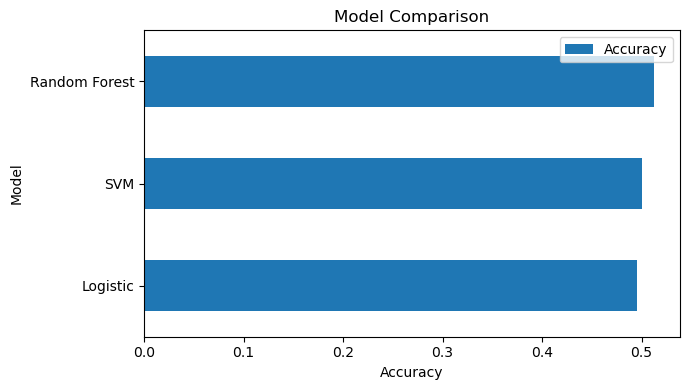

In [7]:
# ============================================
# RQ2: Model Comparison (FINAL - CLEAN)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ============================================
# 1. LOAD DATA
# ============================================

df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')

# ============================================
# 2. TARGET
# ============================================

target = 'Attack Type'

# ============================================
# 3. CLEAN DATA
# ============================================

drop_cols = ['Timestamp', 'Source IP', 'Destination IP', 'Session ID']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

df = df.dropna()

# ============================================
# 4. PREPARE DATA
# ============================================

X = df.drop(columns=[target])
y = df[target]

# Convert to binary (same as RQ1)
top_class = y.value_counts().index[0]
y = (y == top_class).astype(int)

# Remove high-cardinality columns
threshold = 50
X = X.drop(columns=[col for col in X.columns if X[col].nunique() > threshold])

# Column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Encoder (compatible with sklearn versions)
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', encoder, cat_cols)
])

# ============================================
# 5. SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# 6. MODELS (WITH CLASS BALANCING)
# ============================================

models = {
    "Logistic": Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    
    "Random Forest": Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced'))
    ]),
    
    "SVM": Pipeline([
        ('prep', preprocessor),
        ('model', SVC(probability=True, class_weight='balanced'))
    ])
}

# ============================================
# 7. TRAIN & EVALUATE
# ============================================

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

# ============================================
# 8. SAVE RESULTS
# ============================================

df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\nFinal Results:\n", df_results)

df_results.to_csv("RQ2_table.csv", index=False)

# ============================================
# 9. PLOT
# ============================================

df_results.sort_values("Accuracy").plot(kind="barh", x="Model", y="Accuracy", figsize=(7,4))

plt.title("Model Comparison")
plt.xlabel("Accuracy")

plt.tight_layout()
plt.savefig("RQ2_figure.pdf")
plt.show()